In [50]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np

pd.set_option('display.max_columns', None)
clean_df = pd.read_csv('data/clean_data.csv')

## EDA
### EDA Initial questions
- [x] What were the total scores for GAD, SWL, and SPIN? (histogram)
- [x] How did reported hours played impact the GAD, SWL, and SPIN totals? (chart type?)
- [x] What game(s) are played the most hours per week? (Bar chart)
- [x] Do any factors seem to lead to high GAD, SWL, and SPIN totals? (Grouped bars; Console, Residence, Gender vs totals)
- [ ] What most impacts hours played? (~~Scatter plots;~~ age, gender, residence, console vs hours played) stacked area line graph??


Initial investigation of cleaned data

In [51]:
# clean_df.info()
# clean_df.describe()
clean_df.head()

,Unnamed: 0,S. No.,Date,GAD1_Feeling_nervous,GAD2_Cant_stop_worrying,GAD3_Worrying_too_much,GAD4_Trouble_relaxing,GAD5_Restless,GAD6_Easily_annoyed,GAD7_Feeling_afraid,GADE_Difficulty_in_life_num,GADE_Difficulty_in_life,SWL1_Ideal_life,SWL2_Excellent_conditions,SWL3_Satisfied_with_life,SWL4_Met_wants,SWL5_Change_nothing,Game,Platform,Hours,Earnings,Why_play,League,Non_game_hours,SPIN1_Fear_authority,SPIN2_Distress_blushing,SPIN3_Fear_social_events,SPIN4_Avoid_strangers,SPIN5_Fear_criticism,SPIN6_Avoid_embarrassment,SPIN7_Distress_sweating,SPIN8_Avoid_parties,SPIN9_Avoid_attention,SPIN10_Fear_talking_strangers,SPIN11_Avoid_giving_speeches,SPIN12_Avoid_criticism,SPIN13_Distress_heart,SPIN14_Fear_observation,SPIN15_Fear_embarrassment,SPIN16_Avoid_authority,SPIN17_Distress_trembling,Narcissism,Gender,Age,Work,Degree,Reference,Play_style,Accept,GAD_Total,SWL_Total,SPIN_Total,Residence_ISO3,Birthplace_ISO3
0,0,1,2015-02-17,0,0,0,0,1,0,0,0,Not difficult at all,3,5,5,5,5,Skyrim,"Console (PS, Xbox, ...)",15,I play for fun,having fun,unknown,0,1,0,0,1,0,0,1,0,0,0,0,0,0,1,0,1,0,1.0,Male,25,Unemployed / between jobs,Bachelor (or equivalent),Reddit,Singleplayer,Accept,1,23,5,USA,USA
1,1,2,2015-02-17,1,2,2,2,0,1,0,1,Somewhat difficult,3,5,2,5,1,Other,PC,8,I play for fun,having fun,unknown,2,2,1,1,3,2,3,1,3,4,0,3,0,1,3,3,1,2,1.0,Male,41,Unemployed / between jobs,Bachelor (or equivalent),Reddit,Multiplayer - online - with strangers,Accept,8,16,33,USA,USA
2,2,3,2015-02-17,0,2,2,0,0,3,1,0,Not difficult at all,2,6,5,2,2,Other,PC,0,I play for fun,having fun,unknown,0,1,0,1,2,3,4,2,1,0,1,1,3,0,2,4,4,2,4.0,Female,32,Employed,Bachelor (or equivalent),Reddit,Singleplayer,Accept,8,17,31,DEU,DEU
3,3,4,2015-02-17,0,0,0,0,0,0,0,0,Not difficult at all,2,5,5,3,2,Other,PC,20,I play for fun,improving,unknown,5,2,0,0,1,3,0,0,0,0,0,1,3,0,0,1,0,0,2.0,Male,28,Employed,Bachelor (or equivalent),Reddit,Multiplayer - online - with online acquaintanc...,Accept,0,17,11,USA,USA
4,4,5,2015-02-17,2,1,2,2,2,3,2,2,Very difficult,2,2,4,5,1,Other,"Console (PS, Xbox, ...)",20,I play for fun,having fun,unknown,1,2,0,0,0,1,0,0,4,2,0,1,0,0,0,0,3,0,1.0,Male,19,Employed,High school diploma (or equivalent),Reddit,Multiplayer - online - with strangers,Accept,14,14,13,KOR,USA


### Histograms
- What is the distribution of test results for each test?
- What is the distribution of hours spent gaming per week?

- Why this chart type?
  - A histogram shows allows for a quick glance to notice trends with this kind of data.
- Conclusions:
  - Hours > A significant amount report about 20 hours/week. **A boxplot may be helpful here**
  - GAD (Generalized Anxiety Disorder) > Results skew towards lower anxiety
  - SWL (Satisfaction With Life) > These results spread the whole spectrum. There is a curve peaking near neutral, with high numbers in both slightly dissatisfied and slightly satisfied.
  - SPIN (Social Phobia Inventory) > Results show the majority have low to mid levels of social anxiety

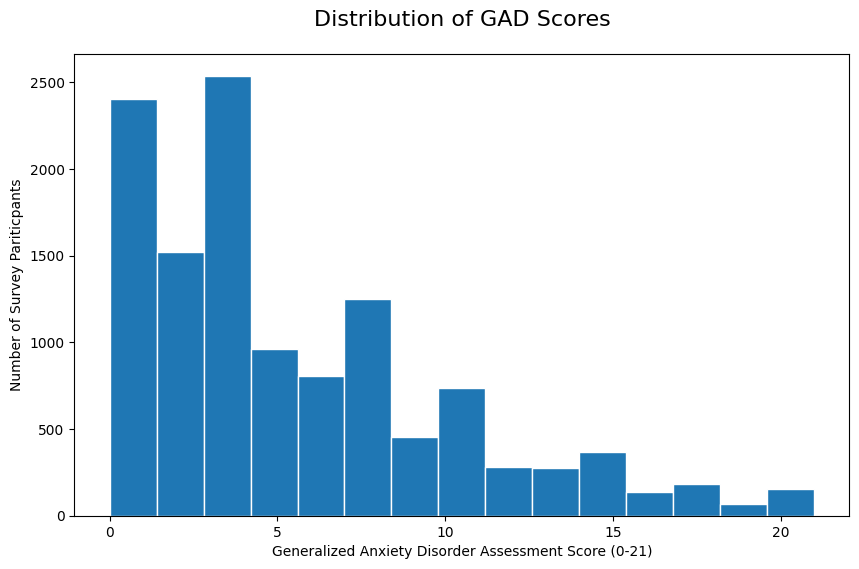

In [52]:
plt.figure(figsize=(10,6))
plt.hist(
    clean_df['GAD_Total'],
    bins=15,
    edgecolor='white'
)

plt.xlabel("Generalized Anxiety Disorder Assessment Score (0-21)")
plt.ylabel("Number of Survey Pariticpants")
plt.title("Distribution of GAD Scores", fontsize=16, pad=20)

# Save figure as image
# plt.savefig('plots/GAD_score_histogram.png')

plt.show()

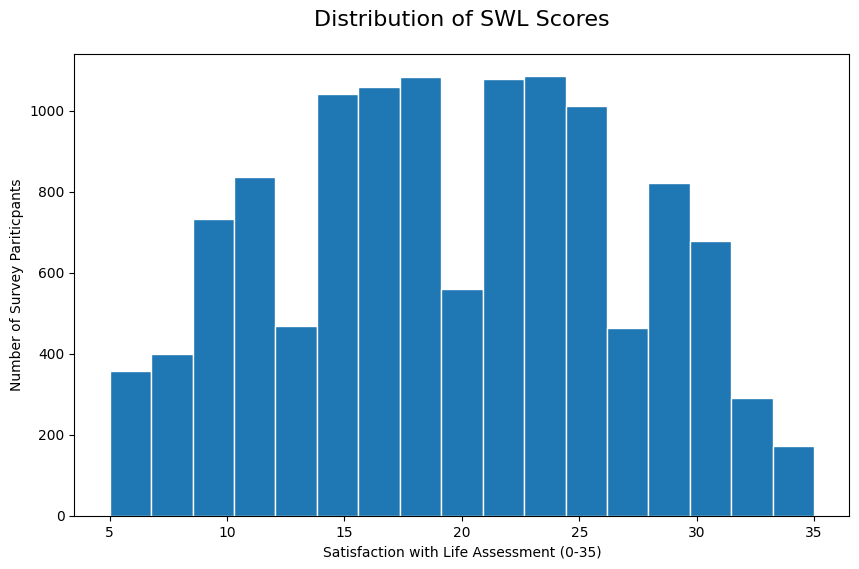

In [53]:
plt.figure(figsize=(10,6))
plt.hist(
    clean_df['SWL_Total'],
    bins=17,
    edgecolor='white'
)

plt.xlabel("Satisfaction with Life Assessment (0-35)")
plt.ylabel("Number of Survey Pariticpants")
plt.title("Distribution of SWL Scores", fontsize=16, pad=20)

# Save figure as image
# plt.savefig('plots/SWL_score_histogram.png')

plt.show()

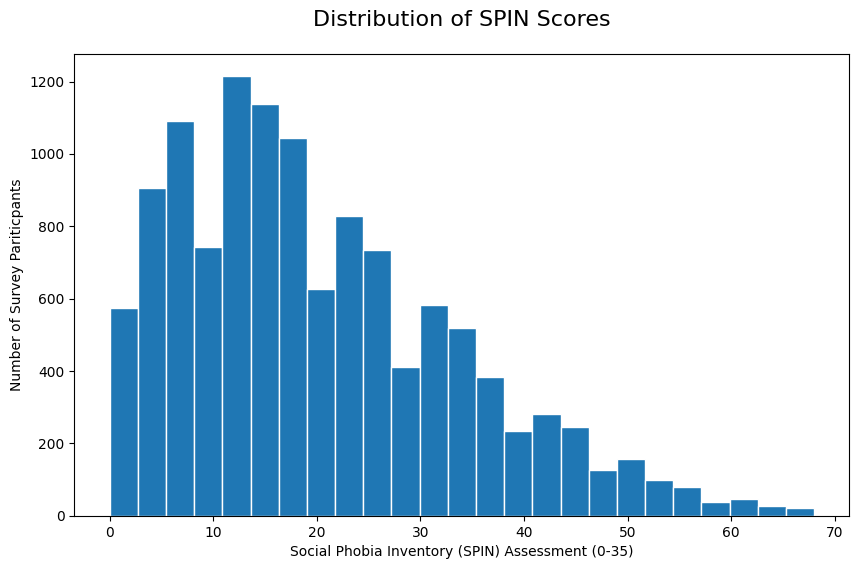

In [54]:
plt.figure(figsize=(10,6))
plt.hist(
    clean_df['SPIN_Total'],
    bins=25,
    edgecolor='white'
)

plt.xlabel("Social Phobia Inventory (SPIN) Assessment (0-35)")
plt.ylabel("Number of Survey Pariticpants")
plt.title("Distribution of SPIN Scores", fontsize=16, pad=20)

# Save figure as image
# plt.savefig('plots/SPIN_score_histogram.png')

plt.show()

In [55]:
clean_df['Hours'].describe()
clean_df['Hours'].value_counts()

Hours
20     2091
10     1244
30     1056
15      999
25      752
       ... 
46        1
160       1
110       1
112       1
96        1
Name: count, Length: 81, dtype: int64

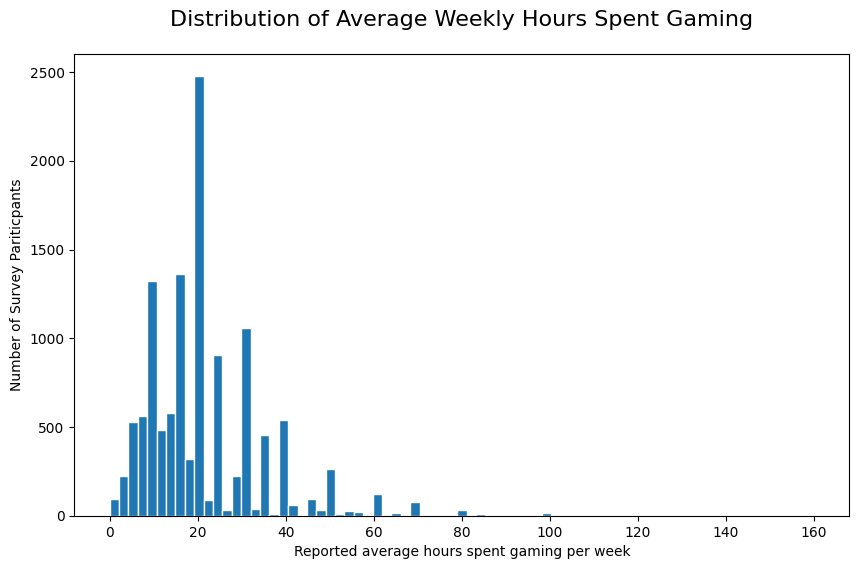

In [56]:
plt.figure(figsize=(10,6))
plt.hist(
    clean_df['Hours'],
    bins=75,
    edgecolor='white'
)

plt.xlabel("Reported average hours spent gaming per week")
plt.ylabel("Number of Survey Pariticpants")
plt.title("Distribution of Average Weekly Hours Spent Gaming", fontsize=16, pad=20)

# Save figure as image
# plt.savefig('plots/Hours_per_week_histogram.png')

plt.show()

### Bar Plot
- How much average time was spent per week on the top-played games?
- Why this chart type?
  -  Bar plot was chosen to see these comparisons side-by-side
- Conclusion: They're closer in duration than expected.

What games are played for the longest duration? Games and Hours  
According to the survey paper, any games with fewer than 10 mentions were grouped under 'Other'

In [57]:
# clean_df.value_counts('Game')

In [58]:
# groupby 'Game' and calculate the avg 'Hours'
avg_hrs_game = clean_df.groupby('Game')['Hours'].mean().sort_values(ascending=False)
avg_hrs_game

Game
Diablo 3               28.675000
World of Warcraft      26.211268
Counter Strike         25.387324
Guild Wars 2           24.848485
Skyrim                 23.304348
Other                  22.108197
League of Legends      21.429955
Heroes of the Storm    20.405405
Destiny                19.555556
Hearthstone            16.602273
Starcraft 2            16.511551
Name: Hours, dtype: float64

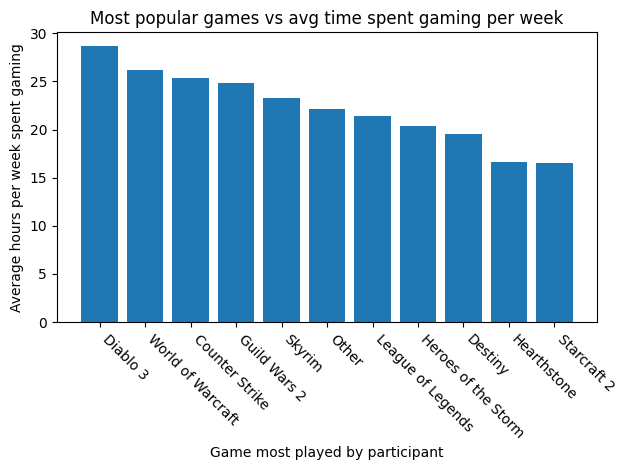

In [59]:
plt.bar(avg_hrs_game.index, avg_hrs_game.values)

plt.xlabel('Game most played by participant')
plt.ylabel('Average hours per week spent gaming')
plt.title('Most popular games vs avg time spent gaming per week')
plt.xticks(rotation=-45, ha='left')

plt.tight_layout()
# Save figure as image
# plt.savefig('plots/Pop_game_hours_barplot.png')

plt.show()

### Grouped Bar Charts
- How do these relate to the GAD/SWL/SPIN scores?
  - [x] gender
  - [x] platform
  - [x] residence (top 5 countries)
  - [x] age (binned) 
- Grouped Bar chart selected to easily compare the average results of the three tests with the above categories in one spot.
  - **gender** > GAD was slightly higher in 'Other' gender category and SWL was slightly lower. Males scored significantly lower on their SPIN assessments.
  - **platform** > Smartphone/tablet users scored higher on both SPIN and GAD assessments
  - **residence** (top 5 countries) > Gamers in the UK had slightly higher GAD and SPIN results and lower SWL. (lowest mental health at a glance)
  - **age** (binned) > slight decrease in SPIN score as age increased, other scores were about the same

#### Gender / Scores Grouped Bar Chart

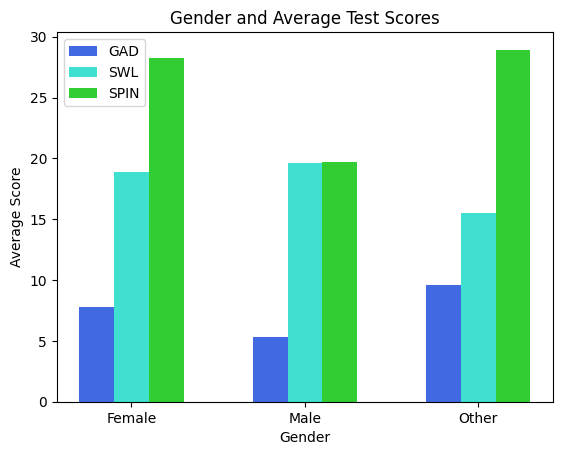

In [60]:
# Reference: https://www.geeksforgeeks.org/python/create-a-grouped-bar-plot-in-matplotlib/

x = np.arange(3)
gender_GAD_scores = clean_df.groupby('Gender')['GAD_Total'].mean() 
gender_SWL_scores = clean_df.groupby('Gender')['SWL_Total'].mean()
gender_SPIN_scores = clean_df.groupby('Gender')['SPIN_Total'].mean()
width=.2 

plt.bar(x-0.2, gender_GAD_scores, width, color='royalblue')
plt.bar(x, gender_SWL_scores, width, color='turquoise')
plt.bar(x+0.2, gender_SPIN_scores, width, color='limegreen')

plt.xticks(x, ['Female', 'Male', 'Other'])
plt.xlabel('Gender')
plt.ylabel('Average Score')
plt.legend(['GAD', 'SWL', 'SPIN'])
plt.title('Gender and Average Test Scores')

# Save figure as image
# plt.savefig('plots/Gender_scores_grouped_bar_chart.png')

plt.show()


In [61]:
# Testing to see which axis is what

# plt.bar(x, gender_GAD_scores, width, color='magenta')

# plt.xticks(x, ['Female', 'Male', 'Other'])
# plt.xlabel('Gender')
# plt.ylabel('Score')
# # plt.legend(['Female', 'Male', 'Other'])

# plt.show()

#### Platform / Scores Grouped Bar Chart

In [62]:
clean_df['Platform'].value_counts()

Platform
PC                         11922
Console (PS, Xbox, ...)      204
Smartphone / Tablet           19
Name: count, dtype: int64

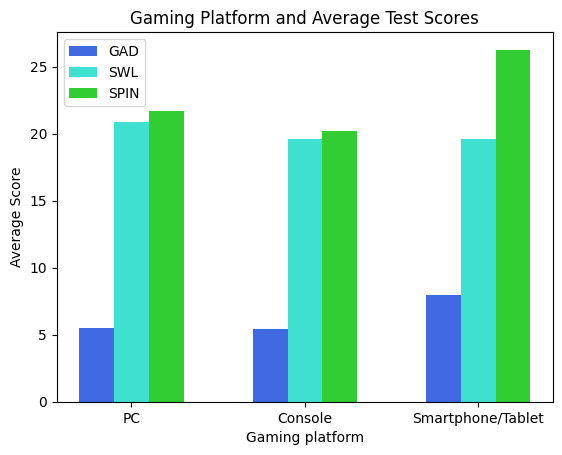

In [63]:
x = np.arange(3)
platform_GAD_scores = clean_df.groupby('Platform')['GAD_Total'].mean() 
platform_SWL_scores = clean_df.groupby('Platform')['SWL_Total'].mean()
platform_SPIN_scores = clean_df.groupby('Platform')['SPIN_Total'].mean()
width=.2 

plt.bar(x-0.2, platform_GAD_scores, width, color='royalblue')
plt.bar(x, platform_SWL_scores, width, color='turquoise')
plt.bar(x+0.2, platform_SPIN_scores, width, color='limegreen')

plt.xticks(x, ['PC', 'Console', 'Smartphone/Tablet'])
plt.xlabel('Gaming platform')
plt.ylabel('Average Score')
plt.legend(['GAD', 'SWL', 'SPIN'])
plt.title('Gaming Platform and Average Test Scores')

# Save figure as image
# plt.savefig('plots/Platform_scores_grouped_bar_chart.png')

plt.show()

#### Residence / Scores Grouped Bar Chart

In [64]:
clean_df['Residence_ISO3'].value_counts().head(10)

Residence_ISO3
USA    4172
DEU    1274
GBR     904
CAN     898
NLD     460
FRA     355
SWE     327
BRA     232
POL     224
DNK     219
Name: count, dtype: int64

In [65]:
# Reference for selecting top 5 countries: https://stackoverflow.com/questions/56920927/selecting-top-n-rows-from-a-categorycolumn-in-a-pandas-dataframe-and-perform-c

# top_countries_GAD = clean_df.groupby('Residence_ISO3',as_index=False).apply(lambda x: x.nlargest(5,'GAD_Total')).mean()
# top_countries_GAD

Make new df with just the top 5 countries represented

In [66]:
top10_countries = clean_df['Residence_ISO3'].value_counts().head(5).index

top10_countries_df = clean_df[clean_df['Residence_ISO3'].isin(top10_countries)]
top10_countries_df['Residence_ISO3'].value_counts()

Residence_ISO3
USA    4172
DEU    1274
GBR     904
CAN     898
NLD     460
Name: count, dtype: int64

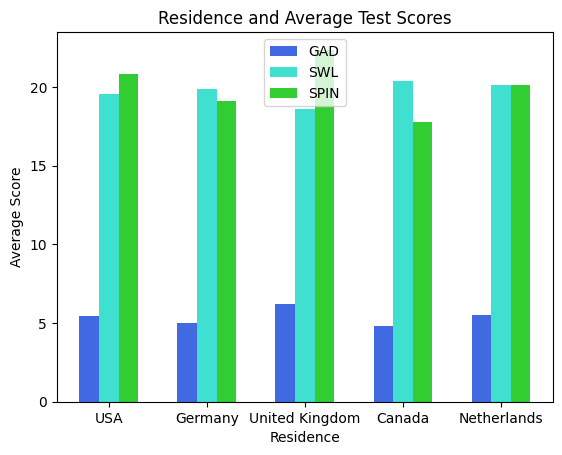

In [67]:
x = np.arange(5)
residence_GAD_scores = top10_countries_df.groupby('Residence_ISO3')['GAD_Total'].mean() 
residence_SWL_scores = top10_countries_df.groupby('Residence_ISO3')['SWL_Total'].mean()
residence_SPIN_scores = top10_countries_df.groupby('Residence_ISO3')['SPIN_Total'].mean()
width=.2 

plt.bar(x-0.2, residence_GAD_scores, width, color='royalblue')
plt.bar(x, residence_SWL_scores, width, color='turquoise')
plt.bar(x+0.2, residence_SPIN_scores, width, color='limegreen')

plt.xticks(x, ['USA', 'Germany', 'United Kingdom', 'Canada', 'Netherlands'])
plt.xlabel('Residence')
plt.ylabel('Average Score')
plt.legend(['GAD', 'SWL', 'SPIN'])
plt.title('Residence and Average Test Scores')

# Save figure as image
# plt.savefig('plots/Residence_scores_grouped_bar_chart.png')

plt.show()

#### Age / Scores Grouped Bar Chart

In [68]:
# top10_countries = clean_df['Residence_ISO3'].value_counts().head(5).index

# top10_countries_df = clean_df[clean_df['Residence_ISO3'].isin(top10_countries)]
# top10_countries_df['Residence_ISO3'].value_counts()

clean_df['Age'].describe()

count    12145.000000
mean        20.936846
std          3.252856
min         18.000000
25%         18.000000
50%         20.000000
75%         22.000000
max         56.000000
Name: Age, dtype: float64

In [69]:
# Bin ages (Reference: https://www.geeksforgeeks.org/python/pandas-cut-method-in-python/)
bins = [18, 20, 22, 26, 60]
labels = ['18-19', '20-22','23-25', '26+']

clean_df['Age_binned'] = pd.cut(clean_df['Age'], bins=bins, labels=labels)

col_to_move = clean_df.pop('Age_binned')
clean_df.insert(43, 'Age_binned', col_to_move)

clean_df.head()
# clean_df.info()

,Unnamed: 0,S. No.,Date,GAD1_Feeling_nervous,GAD2_Cant_stop_worrying,GAD3_Worrying_too_much,GAD4_Trouble_relaxing,GAD5_Restless,GAD6_Easily_annoyed,GAD7_Feeling_afraid,GADE_Difficulty_in_life_num,GADE_Difficulty_in_life,SWL1_Ideal_life,SWL2_Excellent_conditions,SWL3_Satisfied_with_life,SWL4_Met_wants,SWL5_Change_nothing,Game,Platform,Hours,Earnings,Why_play,League,Non_game_hours,SPIN1_Fear_authority,SPIN2_Distress_blushing,SPIN3_Fear_social_events,SPIN4_Avoid_strangers,SPIN5_Fear_criticism,SPIN6_Avoid_embarrassment,SPIN7_Distress_sweating,SPIN8_Avoid_parties,SPIN9_Avoid_attention,SPIN10_Fear_talking_strangers,SPIN11_Avoid_giving_speeches,SPIN12_Avoid_criticism,SPIN13_Distress_heart,SPIN14_Fear_observation,SPIN15_Fear_embarrassment,SPIN16_Avoid_authority,SPIN17_Distress_trembling,Narcissism,Gender,Age_binned,Age,Work,Degree,Reference,Play_style,Accept,GAD_Total,SWL_Total,SPIN_Total,Residence_ISO3,Birthplace_ISO3
0,0,1,2015-02-17,0,0,0,0,1,0,0,0,Not difficult at all,3,5,5,5,5,Skyrim,"Console (PS, Xbox, ...)",15,I play for fun,having fun,unknown,0,1,0,0,1,0,0,1,0,0,0,0,0,0,1,0,1,0,1.0,Male,23-25,25,Unemployed / between jobs,Bachelor (or equivalent),Reddit,Singleplayer,Accept,1,23,5,USA,USA
1,1,2,2015-02-17,1,2,2,2,0,1,0,1,Somewhat difficult,3,5,2,5,1,Other,PC,8,I play for fun,having fun,unknown,2,2,1,1,3,2,3,1,3,4,0,3,0,1,3,3,1,2,1.0,Male,26+,41,Unemployed / between jobs,Bachelor (or equivalent),Reddit,Multiplayer - online - with strangers,Accept,8,16,33,USA,USA
2,2,3,2015-02-17,0,2,2,0,0,3,1,0,Not difficult at all,2,6,5,2,2,Other,PC,0,I play for fun,having fun,unknown,0,1,0,1,2,3,4,2,1,0,1,1,3,0,2,4,4,2,4.0,Female,26+,32,Employed,Bachelor (or equivalent),Reddit,Singleplayer,Accept,8,17,31,DEU,DEU
3,3,4,2015-02-17,0,0,0,0,0,0,0,0,Not difficult at all,2,5,5,3,2,Other,PC,20,I play for fun,improving,unknown,5,2,0,0,1,3,0,0,0,0,0,1,3,0,0,1,0,0,2.0,Male,26+,28,Employed,Bachelor (or equivalent),Reddit,Multiplayer - online - with online acquaintanc...,Accept,0,17,11,USA,USA
4,4,5,2015-02-17,2,1,2,2,2,3,2,2,Very difficult,2,2,4,5,1,Other,"Console (PS, Xbox, ...)",20,I play for fun,having fun,unknown,1,2,0,0,0,1,0,0,4,2,0,1,0,0,0,0,3,0,1.0,Male,18-19,19,Employed,High school diploma (or equivalent),Reddit,Multiplayer - online - with strangers,Accept,14,14,13,KOR,USA


In [70]:
clean_df['Age_binned'].value_counts()

Age_binned
18-19    3624
20-22    2417
23-25    2173
26+       744
Name: count, dtype: int64

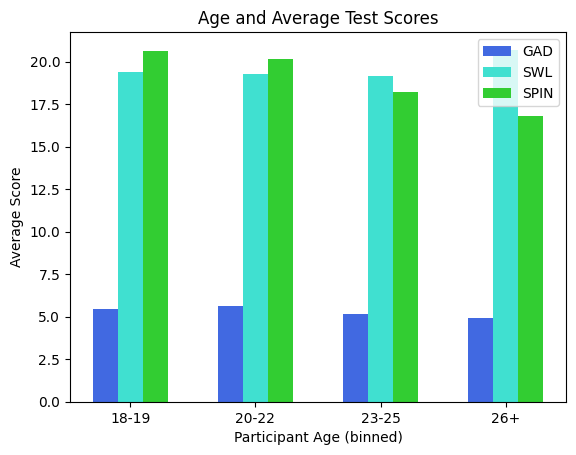

In [71]:
x = np.arange(4)
age_GAD_scores = clean_df.groupby('Age_binned')['GAD_Total'].mean() 
age_SWL_scores = clean_df.groupby('Age_binned')['SWL_Total'].mean()
age_SPIN_scores = clean_df.groupby('Age_binned')['SPIN_Total'].mean()
width=.2 

plt.bar(x-0.2, age_GAD_scores, width, color='royalblue')
plt.bar(x, age_SWL_scores, width, color='turquoise')
plt.bar(x+0.2, age_SPIN_scores, width, color='limegreen')

plt.xticks(x, ['18-19', '20-22','23-25', '26+'])
plt.xlabel('Participant Age (binned)')
plt.ylabel('Average Score')
plt.legend(['GAD', 'SWL', 'SPIN'])
plt.title('Age and Average Test Scores')

# Save figure as image
# plt.savefig('plots/Age_scores_grouped_bar_chart.png')

plt.show()

## Scatterplots
- How does age correspond with hours played each week?
- Scatterplot was chosen to quickly see a visual representation and skew. In hindsight, houwever, this is not the best plot to use for this analysis.
- As suspected, younger participants report more gaming hours each week.

In hindsight, this was not the best type of chart for this analysis, though you can see a downward trend of hours played as age increases.

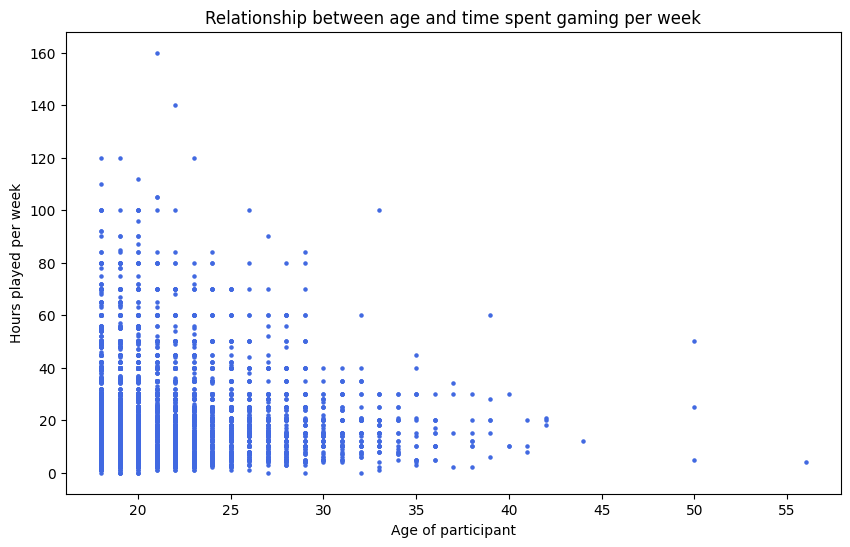

In [72]:
plt.figure(figsize=(10,6))
plt.scatter(
    clean_df['Age'],
    clean_df['Hours'],
    color='royalblue',
    s = 5
)

plt.xlabel('Age of participant')
plt.ylabel('Hours played per week')
plt.title('Relationship between age and time spent gaming per week')

# Save figure as image
# plt.savefig('plots/Age_hours_scatterplot.png')

plt.show()